# ORIE 4580/5580/5581 Assignment 5

#### Students: H. Mariappa (hm559) and T. Kigga (tck38)

### Github link: https://github.com/010105/ORIE4580


### Instructions


* Due Thursday, November 6, at 11.59pm on Gradescope.
* Assignment .ipynb files available for download on [Canvas](https://canvas.cornell.edu/courses/80773#:~:text=Assignments-,Assignments,-Assignments%20module%20publish). Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Ideally do assignments in groups of 2, and submit a single pdf with both names
* Please show your work and clearly mark your answers.
* You can use any code fragments given in class, found online (for example, on StackOverflow), or generated via Gemini/Claude/ChatGPT (you are encouraged to use these for first drafts) **with proper referencing**.
* You can also discuss with others (again, please reference them if you do so); but you must write your final answers on your own as a team.



### Suggested reading

Chapters 8 (all parts) and 9 (up to Section 9.2 for the midterm) of [Simulation by Ross](https://catalog.library.cornell.edu/catalog/12745977).


<hr><hr>

# Question 1: Red-Tailed Hawks! (15 points)

(Dedicated to [Big Red and Arthur](https://www.youtube.com/watch?v=diIn5tc8AJo), and their amazing family!)

A School of Ornithology researcher wants to estimate the number of red-tailed hawks in Ithaca. She radio tags 10 birds, and then sets up a feeding station with automatic camera.

The researcher believes that each individual bird's visits to the feeder can be modeled as a *Poisson process* with some unknown rate $\lambda$; we will talk more about the Poisson process in detail later in the semester (for a quick refresher, see Section 2.9.4 of Ross), but for this question, the main thing you need to know is that this is a process that counts a discrete number of arrivals, where the *inter-arrival* between one arrival and the next is independent and identically distributed as an Exponential$(\lambda)$ random variable (similar to the trains in question 5b in the previous assignment).

**(a)**
Over the first five weeks, the researcher observes an average of 28.8 birds (tagged and untagged) visiting the feeder, with an average of 6 tagged birds per week. Use the method of moments to obtain an estimate for the total population.

<hr>

## Ans.

10 birds tagged

Mean of a poisson is λ. The method of moment estimate would be. $\bar{X}$ = $λ_{MoM}$.


$\frac{λ_{tagged}}{λ_{total}}$ = $\frac{10}{N_{MoM}}$

$\frac{6}{28.8}$ = $\frac{10}{N_{MoM}}$

$N_{MoM}$ = 48

<hr>

**(b)** Next, the researcher develops a video processing program which can identify and distinguish different individual birds from their pictures. Using this, over the next week, she observes 20 unique birds visiting the feeding station, out of which 4 are tagged. What is the MLE for the size of the hawk population in Ithaca?

<hr>

## Ans.



In [1]:
import numpy as np
# Originally tagged birds
M = 10

# Total birds visited
n = 20

# Total birds tagged which visited
x = 4

print(n * M / x)

50.0


<hr><hr>

# Question 2: Soup for Lunch? (15 points)

The folks at the [Temple of Zeus](https://as.cornell.edu/about/temple-of-zeus) have the best soup offerings at Cornell -- however, by the time you are done with Simulation, they often run out of soup. To remedy this, you want to try and understand the demand for soup, so that you can suggest how much they should make. You decide to model the total demand $N$ for soups each day as a geometric random variable with parameter $p$ (i.e., $P(N = k) = (1-p)^kp$, $k \ge 0$).

The Temple of Zeus manager gives you data for the number of lunches sold in the last $100$ days. One problem though is that the data is *censored*: the staff prepared soup for at most $40$ servings each day, and as a result, the number of sales each day is between 0 and 40. As a result, on days when the number of soups sold is $40$, you cannot be sure what the true demand $N_i$ was (but you know $N_i\geq 40$); on other days, the number of soups sold is the true demand $N_i<40$.

<hr>

**(a)**
What is the probability mass function of the per-day sales $Y$ in terms of $p$?

<hr>

## Ans.
$P(N = k) = (1-p)^kp$, $k \ge 0$

Because the sales can only go up to 40,
Y = min(N, 40)

We will need to split into cases where demand is less than 40 or 40.

P(Y = y) =
\begin{cases}
(1 - p)^y \, p, & \text{for } 0 \leq y \leq 39, \\[6pt]
(1 - p)^{40}, & \text{for } y = 40.
\end{cases}



<hr>

**(b)** Compute a maximum likelihood estimator of $p$ based on the sales data for soup given in `Soup_sales_data.csv`.

<hr>

## Ans.


In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar

df = pd.read_csv("Soup_sales_data.csv")
Y = df["Y"]

n_true = (df["Y"] < 40).sum()
n_censored = (df["Y"] == 40).sum()
sum_Y = df.loc[df["Y"] < 40, "Y"].sum()

p_hat = n_true / (n_censored + sum_Y + 40 * n_censored)

print("Analytic MLE for p =", p_hat)

Analytic MLE for p = 0.027149321266968326


<hr><hr>

# Question 3: The Birthday Paradox (40 pts)

In this question, we investigate the celebrated [birthday paradox](https://en.wikipedia.org/wiki/Birthday_problem)!

<hr>

**(a)** The basic question you may have seen in earlier probability courses is the following: given a party of $n$ people whose birthdays are drawn uniformly over the $365$ days in the year, what is the probability that at least two people share a birthday. Derive an expression for the probability, and plot it for $n\in\{10,11,12,\ldots,49,50\}$.

<hr>

## Ans.

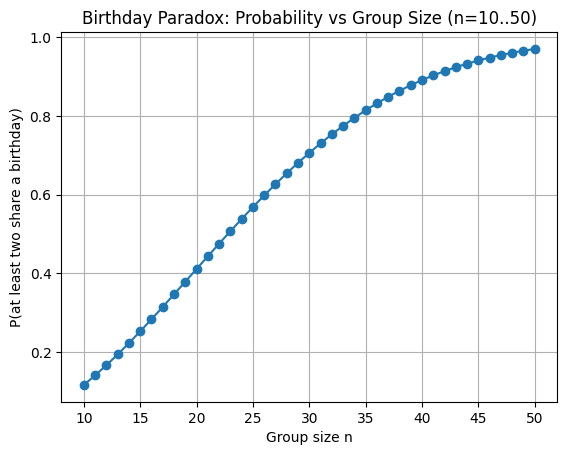

In [3]:
import matplotlib.pyplot as plt

def p(n, days=365):
    # 1 - probability all birthdays are distinct
    if n > days:
        return 1.0
    prod = 1.0
    for k in range(n):
        prod *= (days - k) / days
    return 1 - prod

ns = np.arange(10, 51)
ps = np.array([p(n) for n in ns])

# Used ChatGPT to help plot & put expression into code
plt.figure()
plt.plot(ns, ps, marker='o')
plt.xlabel('Group size n')
plt.ylabel('P(at least two share a birthday)')
plt.title('Birthday Paradox: Probability vs Group Size (n=10..50)')
plt.grid(True)
plt.show()

<hr>

**(b)** Next, we want to obtain the above probabilities by simulation. For a given $n$, perform simulations so as to estimate the probability  of at least two people sharing birthdays in a group of $n$, for $n\in\{15,16,\ldots,30\}$, up to $2$ decimal places (with $95\%$ confidence). Plot the estimates and $95\%$ CI, and also plot the theoretical result from part $(a)$ in the same plot.

<hr>

## Ans.

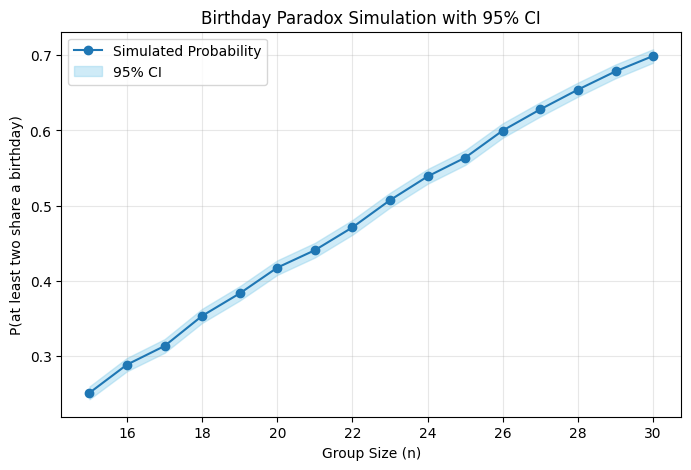

In [4]:
def sim(n, days=365):
  birthdays = np.random.randint(1, days + 1, n)
  unique_birthdays, counts = np.unique(birthdays, return_counts=True)
  return np.any(counts > 1)

def simulate_probs(n_values, trials=10000):
    probs = []
    ci_lower = []
    ci_upper = []

    for n in n_values:
        results = np.array([sim(n) for _ in range(trials)], dtype=int)
        p_hat = results.mean()
        se = np.sqrt(p_hat * (1 - p_hat) / trials)
        ci = 1.96 * se
        probs.append(p_hat)
        ci_lower.append(p_hat - ci)
        ci_upper.append(p_hat + ci)

    return np.array(probs), np.array(ci_lower), np.array(ci_upper)

n_values = np.arange(15, 31)
probs, ci_lower, ci_upper = simulate_probs(n_values)

#Used Chat GPT to make graph with CI
plt.figure(figsize=(8,5))
plt.plot(n_values, probs, label="Simulated Probability", marker='o')
plt.fill_between(n_values, ci_lower, ci_upper, color='skyblue', alpha=0.4, label="95% CI")

plt.title("Birthday Paradox Simulation with 95% CI")
plt.xlabel("Group Size (n)")
plt.ylabel("P(at least two share a birthday)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<hr>

**(c)** One flaw in our analysis is that birth-dates may not be uniformly distributed throughout the year. To check this, we can look at data of real birth-dates.

The file `bdaydata.txt` has a list of $365$ days in the year (excluding February $29$) and the corresponding number of birthdays on that date. Load the dataset and plot the following:

i. Empirical histogram of the data

ii. Empirical cdf

iii. Q-Q plot comparing the data to a uniform distribution

(Dataset based on life insurance data from 1981-94; data and example courtesy [Roy Murphy](http://www.panix.com/~murphy/bday.html).)

<hr>

In [5]:
df = pd.read_csv(
    "bdaydata.txt",
    sep=r"\s+",
    header=0,
    dtype={"date": str, "count": int}
)

In [6]:
df.head()

,date,count
0,0101,1482
1,0102,1213
2,0103,1220
3,0104,1319
4,0105,1262


<Figure size 800x400 with 0 Axes>

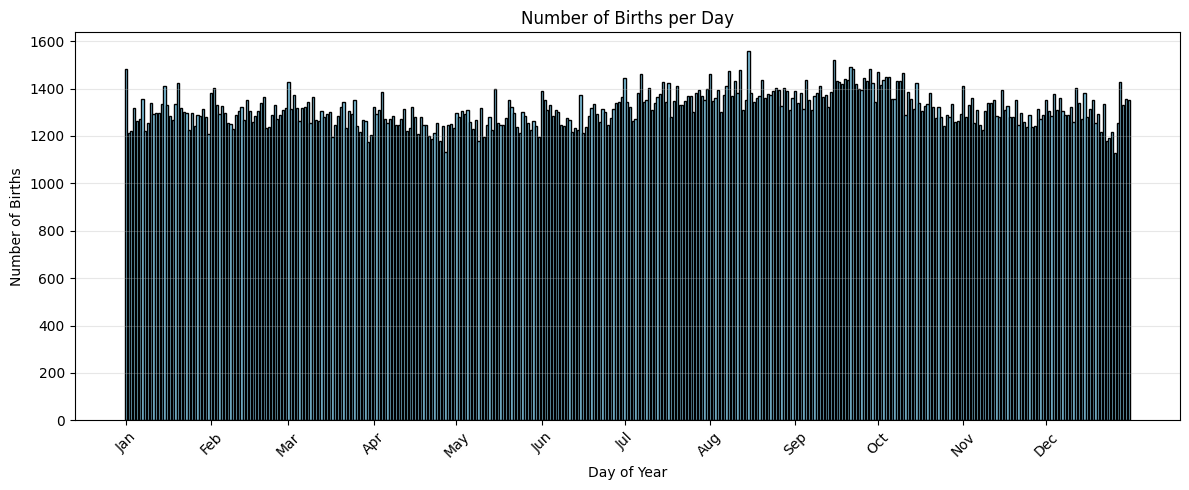

In [7]:
## Empirical Histogram
import calendar

plt.figure(figsize=(8,4))
df["day"] = range(1, len(df) + 1)

plt.figure(figsize=(12,5))
plt.bar(df["day"], df["count"], color="skyblue", edgecolor="black")

plt.title("Number of Births per Day")
plt.xlabel("Day of Year")
plt.ylabel("Number of Births")

#Used ChatGPT to help with labelling and clarity of days to months
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
plt.xticks(month_starts, calendar.month_abbr[1:], rotation=45)

plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

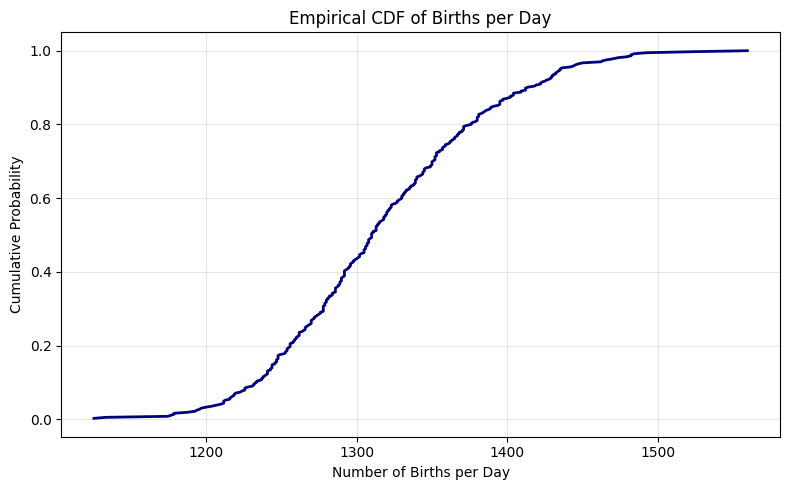

In [8]:
# Empirical CDF

#used ChatGPT to template how to use ECDF
from statsmodels.distributions.empirical_distribution import ECDF
ecdf = ECDF(df["count"])

# Plot CDF
plt.figure(figsize=(8,5))
plt.plot(ecdf.x, ecdf.y, color='navy', lw=2)
plt.title("Empirical CDF of Births per Day")
plt.xlabel("Number of Births per Day")
plt.ylabel("Cumulative Probability")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

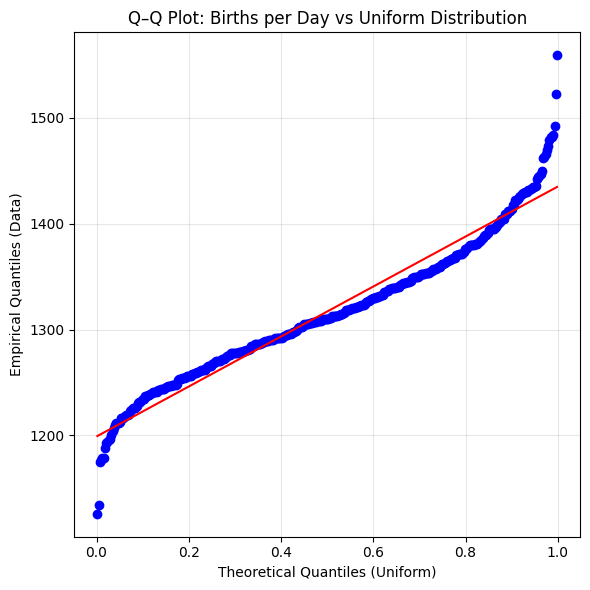

In [9]:
## Q-Q plot
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(df["count"], dist="uniform", plot=plt)

plt.title("Q–Q Plot: Births per Day vs Uniform Distribution")
plt.xlabel("Theoretical Quantiles (Uniform)")
plt.ylabel("Empirical Quantiles (Data)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Ans.

<hr>

**(d)** Perform a Chi-square Test **and** a Kolmogorov-Smirnov Test to study how well the data is modeled by a uniform distribution.

<hr>

## Ans.


In [10]:
# Code from demo 7
def emp_cdf(x, cont_corr=True):
    """
    Calculate the empirical cumulative distribution function (CDF) of a dataset.

    Parameters:
    x (array-like): The dataset for which to calculate the empirical CDF.
    cont_corr (bool, optional): Whether to apply continuity correction. Default is True.

    Returns:
    tuple: A tuple containing two arrays: the sorted dataset and the empirical CDF.
    """
    n = len(x)
    x_sort = np.sort(x)

    if cont_corr:
        # Apply continuity correction
        cdf = (np.arange(1, n + 1) - 0.5) / n
    else:
        # No continuity correction
        cdf = (1.0 * np.arange(1, n + 1)) / n

    return x_sort, cdf

In [11]:
## Chi-square test

data = df['count'].astype(int).values
final_data = (data - np.min(data))/ (np.max(data) - np.min(data))

n = len(final_data)
# Help taken from demo code 7
# Set the minimum expected frequency (E_min) and compute the number of bins (k)
E_min = 6.0
k = int(n/E_min)

# Set the value of s and compute the degrees of freedom (df) for the chi-squared test
s = 0
df = k - s - 1

# Define the bins based on the exponential distribution with the estimated lambda (lam_est)
bins = np.linspace(0,1,k+1)

# Compute the observed histogram and expected frequencies
obs, bins = np.histogram(final_data, bins=bins)
exp = np.ones(k) * (n/k)

# Calculate the chi-squared test statistic (D^2)
D_2 = np.sum((obs - exp)**2/exp)

# Print the result of the chi-squared test
print("The Chi-Square Test statistic is D^2 = " + str(D_2))


The Chi-Square Test statistic is D^2 = 326.89041095890406


The KS statistic is D = 0.24289917



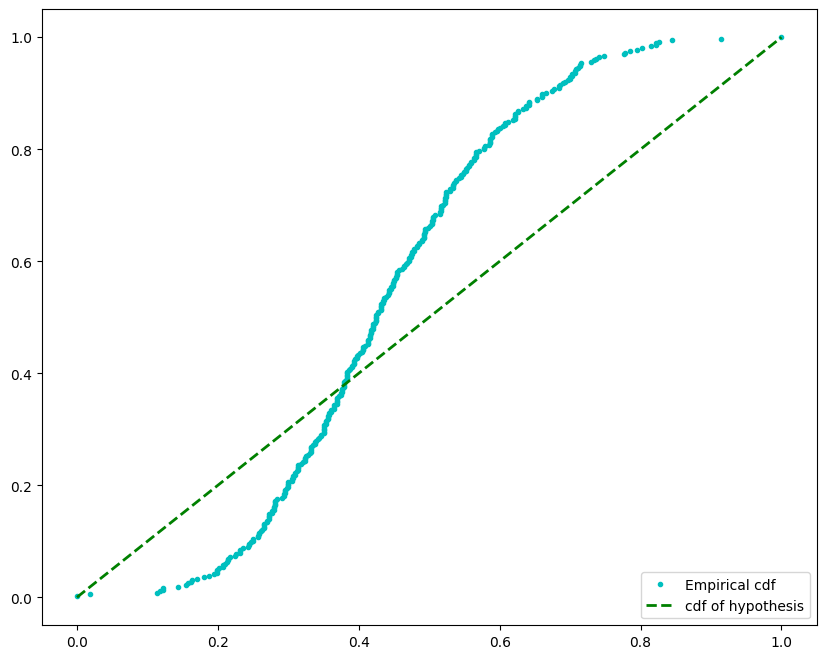

In [12]:
## K-S test
# Help taken from demo code 7
# Compute the empirical CDF of the dataset
from scipy.stats import uniform
X_sort, X_ecdf = emp_cdf(final_data, cont_corr=False)

# Create a new figure for plotting
plt.figure(figsize=[10, 8])

# Plot the empirical CDF as a step function with cyan dots
plt.step(X_sort, X_ecdf, 'c.', linewidth=1, where='post', label='Empirical cdf')

# Calculate the CDF of the exponential distribution with the estimated parameter
Hyp_cdf = uniform.cdf(X_sort)

# Plot the CDF of the hypothesis as a green dashed line
plt.plot(X_sort, Hyp_cdf, 'g--', linewidth=2, label='cdf of hypothesis')

# Calculate the Kolmogorov-Smirnov (KS) statistic
D_KS = np.max(np.abs(Hyp_cdf - X_ecdf))

# Print the KS statistic
print("The KS statistic is D = " + str(round(D_KS, 8))+'\n')

# Add a legend to the plot
plt.legend(loc=4)

# Show the plot
plt.show()

<hr>

**(e)** Since you have an extensive dataset of birthday frequency, you can directly use the nonparametric bootstrap to estimate the probability of at least two people sharing birthdays in a group of $n$. Plot the bootstrap estimate and $95\%$ CI for $n\in\{15,16,\ldots,30\}$, and compare against the plot in part $(b)$.

<hr>

## Ans.


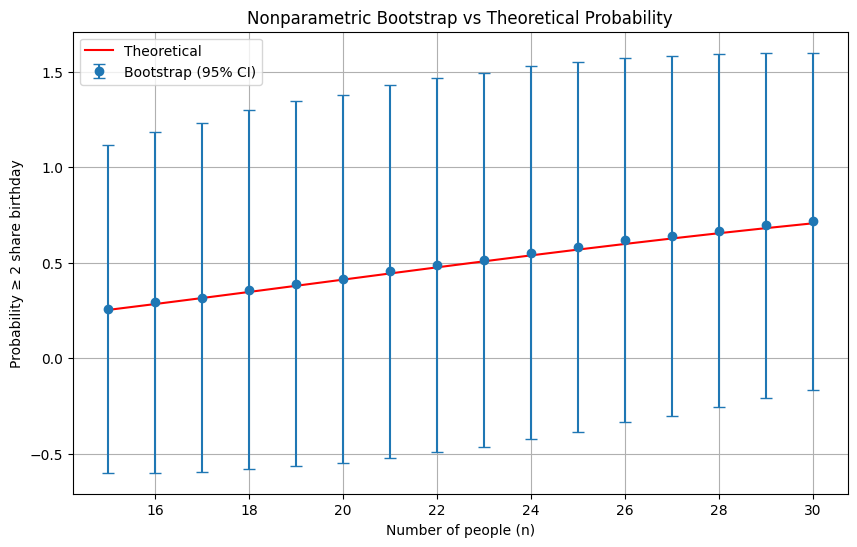

In [14]:
# TODO
# Use bootstrap method: Non parametric
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Nonparametric bootstrap function
def bootstrap_atleast2(data, n_people, num_bootstrap=10000):
  n_data = len(data)
  bootstrap_estimates = []
  for _ in range(num_bootstrap):
  # Sample n_people birthdays with replacement from data
    sample = np.random.choice(data, size=n_people, replace=True)
    # Check if there is at least one duplicate
    bootstrap_estimates.append(len(sample) != len(np.unique(sample)))
  return np.array(bootstrap_estimates)
days = 365
N = 10000
birthdays = np.random.randint(0, days, N)
ns = range(15, 31)
num_bootstrap = 10000
sim_means = []
ci_halfwidths = []
for n_people in ns:
  bst = bootstrap_atleast2(birthdays, n_people, num_bootstrap=num_bootstrap)
  mean = np.mean(bst)
  se = np.std(bst, ddof=1) # bootstrap std
  # 95% CI using normal approximation
  z = stats.norm.ppf(0.975)
  half_width = z*se
  sim_means.append(mean)
  ci_halfwidths.append(half_width)
# Theoretical probability
def P_atleast2_share(n, days=365):
  p_no_share = 1.0
  for k in range(n):
    p_no_share *= (days- k)/days
  return 1 - p_no_share
theoretical = [P_atleast2_share(n) for n in ns]
# Plot results
plt.figure(figsize=(10,6))
plt.errorbar(ns, sim_means, yerr=ci_halfwidths, fmt='o', capsize=4, label='Bootstrap (95% CI)')
plt.plot(ns, theoretical, '-r', label='Theoretical')
plt.xlabel("Number of people (n)")
plt.ylabel("Probability ≥ 2 share birthday")
plt.title("Nonparametric Bootstrap vs Theoretical Probability")
plt.grid(True)
plt.legend()
plt.show()

<hr><hr>

# Question 4: Benford's Law (30 pts)

In this question, we will use the Chi-square test to study *Benford's law* in a variety of setttings. Consider a data set consisting of $n$ different numbers, and look at the leading digit of each number (for example, the leading digit of $123.456$ is $1$, and the leading digit of $-0.423$ is $4$). For many data sets, the fraction of leading digits that equal $1$ is much higher than $1/9$ (i.e., what it would be if uniformlly distributed); in fact, the probability distribution of the different leading digits $1, 2, \ldots, 9$ is far from uniform.

This observation has been observed to hold in measurements of distances to galaxies, numbers appearing in tax forms and many other settings, and has been used to detect fraud among other uses. See [the Wikipedia page](https://en.wikipedia.org/wiki/Benford\%27s_law) for a description of this phenomena, and [this blog post](https://terrytao.wordpress.com/2009/07/03/benfords-law-zipfs-law-and-the-pareto-distribution/) for an interesting related discussion. More recently, this has also been (supposedly) misused in (supposedly) detecting (supposed) fraud in election results -- see [this Stand-Up Maths](https://www.youtube.com/watch?v=etx0k1nLn78&t=4s) video for a great example of how data analysis should be done!



<hr>

**(a)** First, we will study this phenomena in a *synthetic* dataset. For this, compute the first digits of $n!$ for the first $1500$ integers, and plot their empirical histogram. You can use the code fragment provided to generate the first $n$ factorials, or write your own.

<hr>

## Ans.

In [ ]:
from scipy.special import factorial
import matplotlib.pyplot as plt
n = 1500
fact_series = factorial(np.arange(n),exact=True)
first_digit = np.zeros(n)
for i in range(n):
  first_digit[i] = int(str(fact_series[i])[0])

# plot the empirical histogram
# Used Chat gpt to help with the formula
# The empirical probability formula is: P(E)=(number of times an event occurs)/(total number of trials)

unique, counts = np.unique(first_digit, return_counts=True)
empirical_probs = counts / np.sum(counts)

# Crate the histogram
plt.figure(figsize=(10, 6))
plt.bar(unique - 0.2, empirical_probs, width=0.5, label='Empirical', alpha=0.7)
plt.xlabel('Leading Digit')
plt.ylabel('Probability')
plt.title('Distribution of Leading Digits in n! (for n = 1 to 1500)')
plt.xticks(np.arange(1, 10))
plt.legend()
plt.show()


<hr>

**(b)** Use a Chi-square test to determine how well the data can be modeled using a uniform distribution.

<hr>

## Ans.

In [ ]:
import numpy as np
from scipy.stats import chi2

unique, counts = np.unique(first_digit, return_counts=True)

N = np.sum(counts)
k = 9
expected = np.ones(k) * N / k

D2 = np.sum((counts - expected)**2 / expected)

df = k - 1

p_value = 1 - chi2.cdf(D2, df)

print(f"Chi-square statistic (D^2): {D2:.4f}")
print(f"P-value: {p_value:.4e}")


Null hypothesis H0​ : Leading digits are uniformly distributed over 1 to 9. Alternative H1: Leading digits are not uniformly distributed.

Since the p value < 0.05 we reject the null hypothesis and we can say that the leading digits of factorials are not uniform.

<hr>

**(c)** Next, use a Chi-square test to test how well the data is modeled using the 'Benford's Law' distribution:
$$p(d)= \log _{10}(d+1)-\log _{10}(d), \quad d\in\{1,2,\ldots,9\}$$


<hr>

In [ ]:
unique, counts = np.unique(first_digit, return_counts=True)
N = np.sum(counts)
k = 9

# Benford's Law
benford_probs = [np.log10(d+1) - np.log10(d) for d in range(1, 10)]
expected = np.array(benford_probs) * N

D2 = np.sum((counts - expected)**2 / expected)

df = k - 1

p_value = 1 - chi2.cdf(D2, df)

print(f"Chi-square statistic (D^2): {D2:.4f}")
print(f"P-value: {p_value:.4e}")


Null hypothesis H0​ : Leading digits follow Benford’s Law
Alternative H1: Leading digits do not follow Benford’s Law

Since the p value (0.305) > 0.05 we fail to reject the null hypothesis and we can say that the Leading digits follow Benford’s Law .

<hr>

**(d)** Finally, we will repeat this analysis with a more natural dataset. The dataset `us_pop.csv` contains the US population in 100,000 different zip codes in the year 2010, and the numbers range from less than ten to almost 100,000. As above, compute the histogram of the leading digits, and use the Chi-square test to see how well the data is modeled via the uniform and the Benford's law distributions.

<hr>

## Ans.

In [ ]:
df = pd.read_csv("us_pop.csv")
#df.head()
population = df['population'].values
def leading_digit(num):
    return int(str(int(num))[0])

first_digit = np.array([leading_digit(x) for x in population])

unique, counts = np.unique(first_digit, return_counts=True)
empirical_probs = counts / np.sum(counts)
#benford_probs = [np.log10(d+1) - np.log10(d) for d in range(1, 10)]


plt.figure(figsize=(10,6))
plt.bar(np.arange(1,10)-0.2, empirical_probs, width=0.5, label='Empirical', alpha=0.7)
plt.xlabel('Leading Digit')
plt.ylabel('Probability')
plt.title('Leading Digit Distribution of US Populations (2010)')
plt.xticks(np.arange(1,10))
plt.legend()
plt.show()


In [ ]:
#Uniform
N = np.sum(counts)
k = 9

expected_uniform = np.ones(k) * N / k
D2_uniform = np.sum((counts - expected_uniform)**2 / expected_uniform)
df = k - 1
p_uniform = 1 - chi2.cdf(D2_uniform, df)

print("Uniform test:")
print(f"Chi-square statistic (D^2): {D2_uniform:.4f}")
print(f"P-value: {p_uniform:.4e}")


In [ ]:
#Benford's Law
benford_probs = [np.log10(d+1) - np.log10(d) for d in range(1, 10)]
expected_benford = np.array(benford_probs) * N
D2_benford = np.sum((counts - expected_benford)**2 / expected_benford)
p_benford = 1 - chi2.cdf(D2_benford, df)

print("\nBenford test:")
print(f"Chi-square statistic (D^2): {D2_benford:.4f}")
print(f"P-value: {p_benford:.4e}")


From the above p values we can see that for Uniform test since p value < 0.05 we reject uniformity.
For Benford test since p value > 0.05 we fail to reject. We can say that Leading numbers follow Benfords Law distribution.

**(e) (Optional for all students)** To understand how the Benford's law distribution originates, the important idea is that when a random variable $X$ ranges over several orders (say between $0$ and $10^6$), then it is better modelled by saying that $\log_{10}(X)$ is uniformly distributed on interval $[0,6]$ (rather than $X$ being uniform on $[0,10^6]$. Using this, can you derive the the exact probabilities for each of the leading digits.